# Análise de séries temporais

- Projeto: **MITHA - Mini Tomato Hydration Assistant**
- Disciplina: **Projeto Integrador IV**
- Conjuntos de dados processados: safras **2023, 2024 e 2025**
- Continuação de: `01_analise_exploratoria.ipynb`

---

Este notebook investiga a **estrutura temporal** dos dados antes da validação de hipóteses ou do treinamento de modelos.

Os principais objetivos são:

1. verificar a cobertura temporal de cada safra e linha de cultivo;
2. identificar lacunas e irregularidades entre observações;
3. visualizar conjuntamente variáveis ambientais, de solo e de irrigação;
4. avaliar dependência temporal por meio de autocorrelação;
5. preparar uma base metodológica para a análise temporal da hipótese H3.

**Importante:** nenhuma interpolação é realizada automaticamente. Ao regularizar a grade temporal em intervalos de 10 minutos, os períodos sem observação permanecem como `NaN`.

## PRÉ-INÍCIO

- Carregamento das bibliotecas;
- leitura dos conjuntos de dados processados;
- conversão de `timestamp_10min` para datetime;
- definição da frequência temporal utilizada nas análises.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

FREQ = "10min"
PASSOS_POR_HORA = 6

In [3]:
# @title Leitura dos conjuntos de dados

DATA_DIR = Path("../data/processed")

arquivos = {
    "2023": DATA_DIR / "dataset_m2_2023.csv",
    "2024": DATA_DIR / "dataset_m2_2024.csv",
    "2025": DATA_DIR / "dataset_m2_2025.csv",
}

datasets = {}

for safra, caminho in arquivos.items():
    if not caminho.exists():
        raise FileNotFoundError(
            f"Arquivo não encontrado: {caminho}\n"
            "Execute primeiro o script merge_m2.py."
        )

    df = pd.read_csv(caminho, low_memory=False)
    df["timestamp_10min"] = pd.to_datetime(
        df["timestamp_10min"], errors="coerce", utc=True
    )

    datasets[safra] = df

    print(
        f"Safra {safra}: "
        f"{df.shape[0]:,} linhas × {df.shape[1]} colunas"
    )

Safra 2023: 32,877 linhas × 19 colunas
Safra 2024: 46,635 linhas × 19 colunas
Safra 2025: 86,590 linhas × 19 colunas


## COBERTURA E REGULARIDADE TEMPORAL

Embora a variável `timestamp_10min` represente janelas de 10 minutos, isso não garante que exista uma observação em **todos** os intervalos.

Nesta etapa são analisados:

- início e fim da série;
- quantidade de timestamps observados;
- intervalo mediano entre registros;
- maior lacuna encontrada;
- quantidade de lacunas superiores a 10 minutos, 1 hora e 6 horas.

A análise é feita por **safra** e por **linha de cultivo (`line`)**.

In [4]:
# @title Resumo da cobertura temporal por safra e linha

resumo_temporal = []

for safra, df in datasets.items():

    linhas = sorted(df["line"].dropna().unique())

    for linha in linhas:
        timestamps = (
            df.loc[df["line"] == linha, "timestamp_10min"]
            .dropna()
            .drop_duplicates()
            .sort_values()
        )

        if timestamps.empty:
            continue

        deltas = timestamps.diff().dropna()
        deltas_min = deltas.dt.total_seconds() / 60

        resumo_temporal.append({
            "safra": safra,
            "line": linha,
            "inicio": timestamps.iloc[0],
            "fim": timestamps.iloc[-1],
            "timestamps_observados": len(timestamps),
            "duracao_dias": (
                timestamps.iloc[-1] - timestamps.iloc[0]
            ).total_seconds() / 86400,
            "intervalo_mediano_min": deltas_min.median()
                if len(deltas_min) else np.nan,
            "maior_gap_horas": deltas_min.max() / 60
                if len(deltas_min) else np.nan,
            "gaps_maior_10min": int((deltas_min > 10).sum()),
            "gaps_maior_1h": int((deltas_min > 60).sum()),
            "gaps_maior_6h": int((deltas_min > 360).sum()),
        })

resumo_temporal = pd.DataFrame(resumo_temporal)

display(resumo_temporal)

,safra,line,inicio,fim,timestamps_observados,duracao_dias,intervalo_mediano_min,maior_gap_horas,gaps_maior_10min,gaps_maior_1h,gaps_maior_6h
0,2023,1,2023-06-29 06:10:00+00:00,2023-09-13 21:50:00+00:00,10959,76.653,10.000,6.833,40,1,1
1,2023,2,2023-06-29 06:10:00+00:00,2023-09-13 21:50:00+00:00,10959,76.653,10.000,6.833,40,1,1
2,2023,3,2023-06-29 06:10:00+00:00,2023-09-13 21:50:00+00:00,10959,76.653,10.000,6.833,40,1,1
3,2024,1,2024-06-12 00:00:00+00:00,2024-09-05 02:30:00+00:00,9327,85.104,10.000,415.333,149,3,3
4,2024,2,2024-06-12 00:00:00+00:00,2024-09-05 02:30:00+00:00,9327,85.104,10.000,415.333,149,3,3
5,2024,3,2024-06-12 00:00:00+00:00,2024-09-05 02:30:00+00:00,9327,85.104,10.000,415.333,149,3,3
6,2024,4,2024-06-12 00:00:00+00:00,2024-09-05 02:30:00+00:00,9327,85.104,10.000,415.333,149,3,3
7,2024,5,2024-06-12 00:00:00+00:00,2024-09-05 02:30:00+00:00,9327,85.104,10.000,415.333,149,3,3
8,2025,1,2025-06-26 05:50:00+00:00,2025-10-28 08:00:00+00:00,17318,124.090,10.000,27.833,232,5,2
9,2025,2,2025-06-26 05:50:00+00:00,2025-10-28 08:00:00+00:00,17318,124.090,10.000,27.833,232,5,2


### Observações sobre as lacunas

Uma lacuna temporal não é tratada automaticamente como erro. Ela pode representar:

1. ausência de coleta;
2. desligamento de sensores;
3. mudança na instrumentação;
4. períodos em que o sistema não registrou determinadas variáveis;
5. comportamento esperado do experimento original.

Por esse motivo, os dados ausentes serão mantidos como `NaN`.

## DISPONIBILIDADE DAS VARIÁVEIS DE INTERESSE

Para a análise temporal envolvendo temperatura do ar e umidade do solo, é importante verificar quais linhas possuem quantidade suficiente de observações simultâneas das duas variáveis.

In [5]:
# @title Quantidade de observações válidas por safra e linha

disponibilidade = []

for safra, df in datasets.items():

    for linha in sorted(df["line"].dropna().unique()):
        temp = df[df["line"] == linha]

        pares_validos = temp[
            ["env_temperature", "soil_humidity"]
        ].dropna()

        disponibilidade.append({
            "safra": safra,
            "line": linha,
            "env_temperature_validos":
                int(temp["env_temperature"].notna().sum()),
            "soil_humidity_validos":
                int(temp["soil_humidity"].notna().sum()),
            "pares_temp_solo_validos": len(pares_validos),
            "valve_state_validos":
                int(temp["valve_state"].notna().sum())
                if "valve_state" in temp.columns else 0,
        })

disponibilidade = pd.DataFrame(disponibilidade)

display(disponibilidade)

,safra,line,env_temperature_validos,soil_humidity_validos,pares_temp_solo_validos,valve_state_validos
0,2023,1,10959,10837,10837,10635
1,2023,2,10959,10823,10823,10770
2,2023,3,10959,10799,10799,10085
3,2024,1,9327,9325,9325,9250
4,2024,2,9327,9325,9325,9272
5,2024,3,9327,9321,9321,9250
6,2024,4,9327,9326,9326,9210
7,2024,5,9327,9325,9325,9236
8,2025,1,17318,17302,17302,17051
9,2025,2,17318,17287,17287,17046


## PREPARAÇÃO DAS SÉRIES

Para operações como `shift`, autocorrelação e correlação com defasagem, a série precisa possuir uma grade temporal regular.

A função abaixo:

- seleciona uma safra e uma linha;
- agrupa eventuais registros repetidos no mesmo instante;
- reamostra os dados em intervalos de 10 minutos;
- **não interpola** os períodos ausentes.

Para `valve_state`, utiliza-se o maior valor dentro da janela (`1` prevalece sobre `0`). Para as variáveis contínuas utiliza-se a média.

In [6]:
# @title Função de preparação de uma série temporal

VARIAVEIS_SERIE = [
    "env_temperature",
    "env_humidity",
    "soil_temperature",
    "soil_humidity",
    "soil_ec",
    "valve_state",
    "water_volume",
]

def preparar_serie_temporal(df, linha, freq=FREQ):
    cols = [
        "timestamp_10min",
        *[c for c in VARIAVEIS_SERIE if c in df.columns]
    ]

    temp = (
        df.loc[df["line"] == linha, cols]
        .dropna(subset=["timestamp_10min"])
        .sort_values("timestamp_10min")
        .copy()
    )

    if temp.empty:
        return pd.DataFrame()

    agregacoes = {}

    for coluna in temp.columns:
        if coluna == "timestamp_10min":
            continue
        elif coluna == "valve_state":
            agregacoes[coluna] = "max"
        elif coluna == "water_volume":
            agregacoes[coluna] = "last"
        else:
            agregacoes[coluna] = "mean"

    serie = (
        temp
        .set_index("timestamp_10min")
        .resample(freq)
        .agg(agregacoes)
    )

    return serie

In [7]:
# @title Exemplo de seleção automática de uma série válida

candidatos = disponibilidade[
    disponibilidade["pares_temp_solo_validos"] > 0
].sort_values(
    ["pares_temp_solo_validos"],
    ascending=False
)

if candidatos.empty:
    raise ValueError(
        "Nenhuma combinação de safra/linha possui "
        "temperatura do ar e umidade do solo simultaneamente."
    )

exemplo = candidatos.iloc[0]

SAFRA_EXEMPLO = str(exemplo["safra"])
LINHA_EXEMPLO = exemplo["line"]

serie_exemplo = preparar_serie_temporal(
    datasets[SAFRA_EXEMPLO],
    LINHA_EXEMPLO
)

print(
    f"Exemplo selecionado: safra {SAFRA_EXEMPLO}, "
    f"linha {LINHA_EXEMPLO}"
)

display(serie_exemplo.head())

Exemplo selecionado: safra 2025, linha 4


,env_temperature,env_humidity,soil_temperature,soil_humidity,soil_ec,valve_state,water_volume
timestamp_10min,,,,,,,
2025-06-26 05:50:00+00:00,26.200,58.500,24.500,46.205,"1,016.000",0.000,"65,394.000"
2025-06-26 06:00:00+00:00,26.000,58.500,24.500,46.205,"1,016.500",0.000,"65,394.000"
2025-06-26 06:10:00+00:00,25.800,58.500,24.500,46.205,"1,015.500",0.000,"65,394.000"
2025-06-26 06:20:00+00:00,25.600,59.000,24.500,46.205,"1,015.000",0.000,"65,394.000"
2025-06-26 06:30:00+00:00,25.700,59.000,24.500,46.170,"1,014.000",0.000,"65,394.000"


## VISUALIZAÇÃO DE UMA JANELA TEMPORAL

Para comparar temperatura e umidade do solo no mesmo gráfico, as séries são padronizadas por **z-score**.

Isso evita que as escalas diferentes das variáveis prejudiquem a comparação visual.

A função permite escolher:

- safra;
- linha;
- data inicial;
- quantidade de dias exibidos.

Quando `inicio=None`, utiliza-se o primeiro instante em que temperatura do ar e umidade do solo estão simultaneamente disponíveis.

In [24]:
# @title Função de visualização temporal normalizada

def plotar_janela_temporal(
    datasets,
    safra,
    linha,
    inicio=None,
    dias=7
):
    serie = preparar_serie_temporal(
        datasets[str(safra)],
        linha
    )

    if serie.empty:
        print("Série vazia.")
        return

    validos = serie[
        ["env_temperature", "soil_humidity"]
    ].dropna()

    if validos.empty:
        print(
            "Não há observações simultâneas de "
            "temperatura do ar e umidade do solo."
        )
        return

    if inicio is None:
        inicio = validos.index.min()
    else:
        inicio = pd.Timestamp(inicio)

        if inicio.tzinfo is None:
            inicio = inicio.tz_localize("UTC")
        else:
            inicio = inicio.tz_convert("UTC")

    fim = inicio + pd.Timedelta(days=dias)

    janela = serie.loc[inicio:fim].copy()

    valores = janela[
        ["env_temperature", "soil_humidity"]
    ]

    medias = valores.mean()
    desvios = valores.std().replace(0, np.nan)

    z = (valores - medias) / desvios

    plt.figure(figsize=(14, 5))

    plt.plot(
        z.index,
        z["env_temperature"],
        label="Temperatura do ar"
    )

    plt.plot(
        z.index,
        z["soil_humidity"],
        label="Umidade do solo"
    )

    plt.axhline(0, linewidth=0.8)

    plt.title(
        f"Série temporal normalizada - "
        f"Safra {safra} - Linha {linha}"
    )

    plt.xlabel("Tempo")
    plt.ylabel("Valor padronizado (z-score)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if "valve_state" in janela.columns:
        plt.figure(figsize=(14, 3))

        plt.step(
            janela.index,
            janela["valve_state"],
            where="post"
        )

        plt.title(
            f"Estado da válvula na mesma janela - "
            f"Safra {safra} - Linha {linha}"
        )

        plt.xlabel("Tempo")
        plt.ylabel("valve_state")
        plt.yticks([0, 1], ["Fechada", "Aberta"])
        plt.tight_layout()
        plt.show()

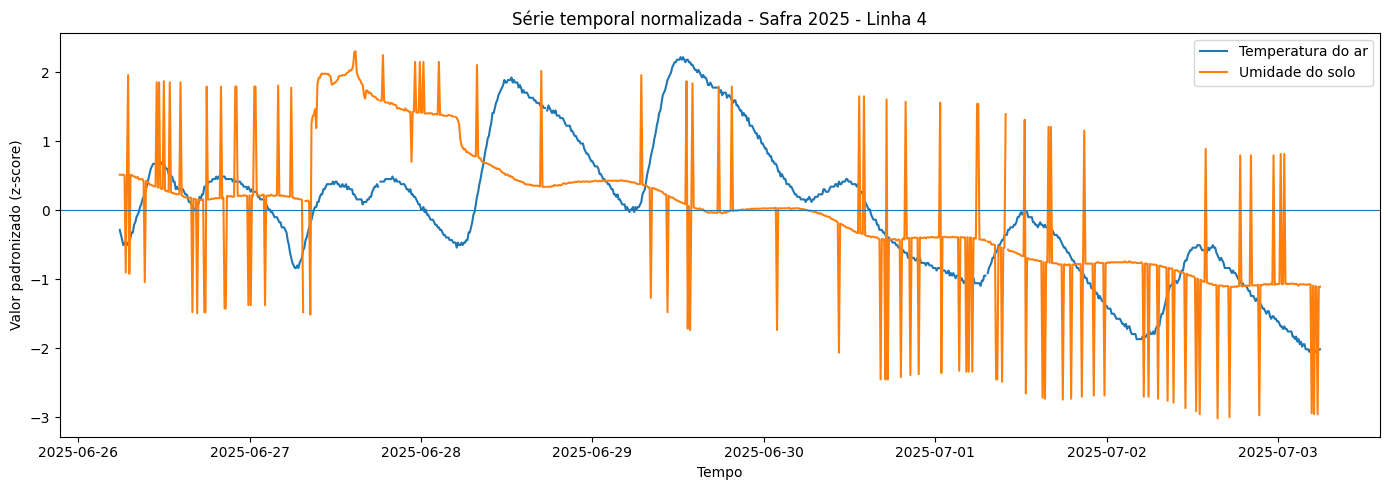

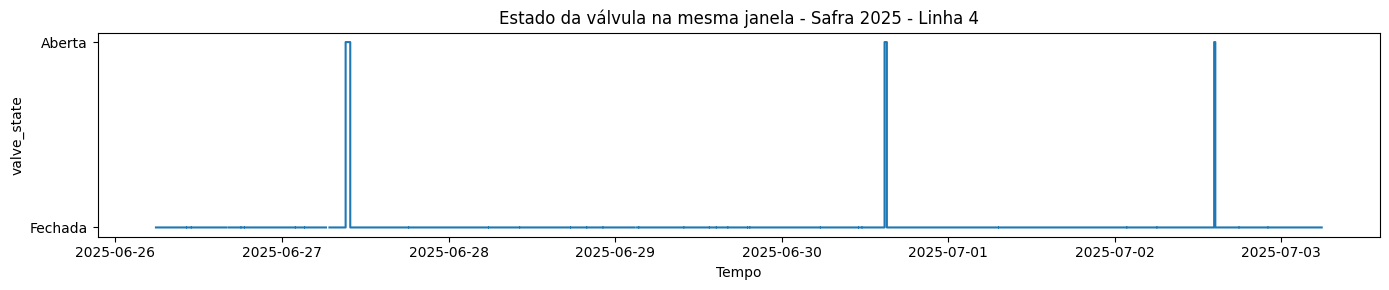

In [25]:
# @title Visualização do exemplo selecionado

plotar_janela_temporal(
    datasets,
    safra=SAFRA_EXEMPLO,
    linha=LINHA_EXEMPLO,
    inicio=None,
    dias=7
)

## AGREGAÇÃO HORÁRIA E DIÁRIA

Séries em resolução de 10 minutos podem apresentar bastante variabilidade.

A agregação não substitui os dados originais, mas ajuda a visualizar tendências em escalas maiores.

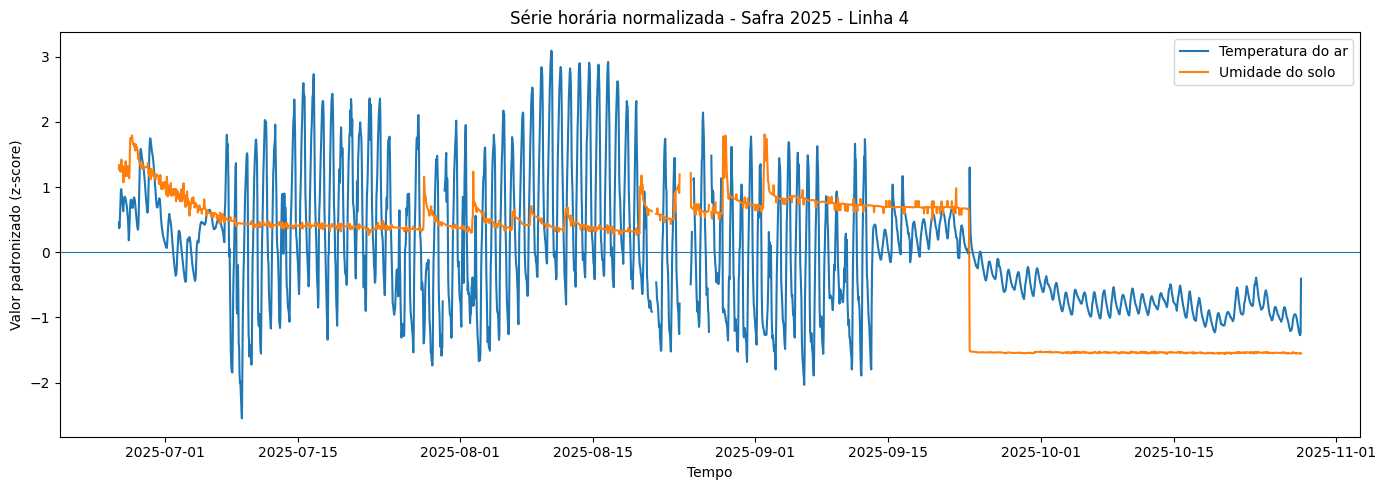

In [26]:
# @title Série horária normalizada do exemplo selecionado

serie_horaria = (
    serie_exemplo[
        ["env_temperature", "soil_humidity"]
    ]
    .resample("1h")
    .mean()
)

medias = serie_horaria.mean()
desvios = serie_horaria.std().replace(0, np.nan)

serie_horaria_z = (
    serie_horaria - medias
) / desvios

plt.figure(figsize=(14, 5))

plt.plot(
    serie_horaria_z.index,
    serie_horaria_z["env_temperature"],
    label="Temperatura do ar"
)

plt.plot(
    serie_horaria_z.index,
    serie_horaria_z["soil_humidity"],
    label="Umidade do solo"
)

plt.axhline(0, linewidth=0.8)
plt.title(
    f"Série horária normalizada - "
    f"Safra {SAFRA_EXEMPLO} - Linha {LINHA_EXEMPLO}"
)
plt.xlabel("Tempo")
plt.ylabel("Valor padronizado (z-score)")
plt.legend()
plt.tight_layout()
plt.show()

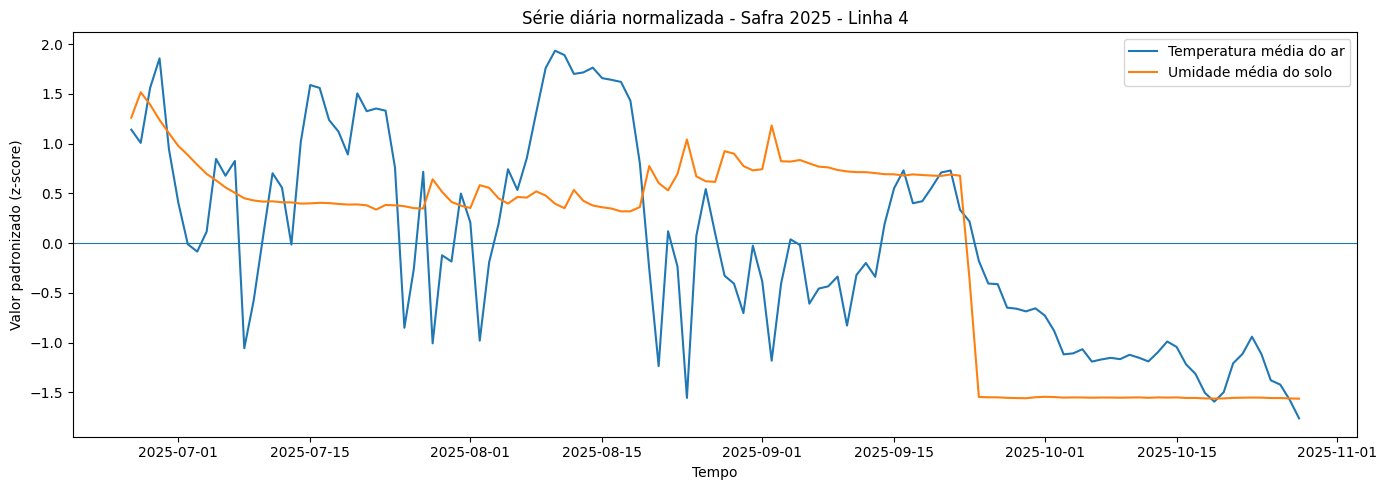

In [27]:
# @title Série diária normalizada do exemplo selecionado

serie_diaria = (
    serie_exemplo[
        ["env_temperature", "soil_humidity"]
    ]
    .resample("1D")
    .mean()
)

medias = serie_diaria.mean()
desvios = serie_diaria.std().replace(0, np.nan)

serie_diaria_z = (
    serie_diaria - medias
) / desvios

plt.figure(figsize=(14, 5))

plt.plot(
    serie_diaria_z.index,
    serie_diaria_z["env_temperature"],
    label="Temperatura média do ar"
)

plt.plot(
    serie_diaria_z.index,
    serie_diaria_z["soil_humidity"],
    label="Umidade média do solo"
)

plt.axhline(0, linewidth=0.8)
plt.title(
    f"Série diária normalizada - "
    f"Safra {SAFRA_EXEMPLO} - Linha {LINHA_EXEMPLO}"
)
plt.xlabel("Tempo")
plt.ylabel("Valor padronizado (z-score)")
plt.legend()
plt.tight_layout()
plt.show()

## PERFIL MÉDIO POR HORA DO DIA

Esta análise permite observar o comportamento médio intradiário das variáveis.

Como `timestamp_10min` é tratado em UTC no pipeline, a hora exibida abaixo também está em **UTC**.

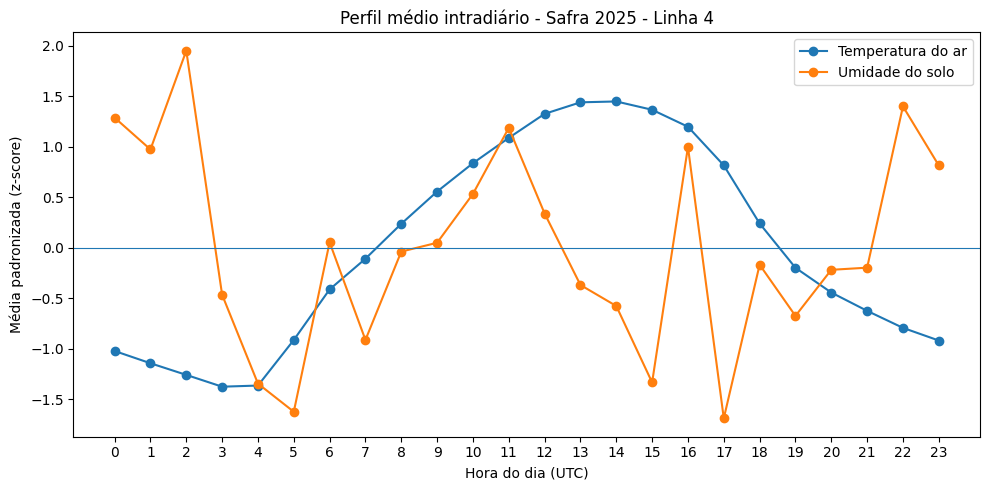

In [28]:
# @title Perfil médio por hora do dia

perfil = serie_exemplo[
    ["env_temperature", "soil_humidity"]
].copy()

perfil["hora_utc"] = perfil.index.hour

perfil_horario = (
    perfil
    .groupby("hora_utc")[
        ["env_temperature", "soil_humidity"]
    ]
    .mean()
)

perfil_z = (
    perfil_horario - perfil_horario.mean()
) / perfil_horario.std().replace(0, np.nan)

plt.figure(figsize=(10, 5))

plt.plot(
    perfil_z.index,
    perfil_z["env_temperature"],
    marker="o",
    label="Temperatura do ar"
)

plt.plot(
    perfil_z.index,
    perfil_z["soil_humidity"],
    marker="o",
    label="Umidade do solo"
)

plt.axhline(0, linewidth=0.8)
plt.title(
    f"Perfil médio intradiário - "
    f"Safra {SAFRA_EXEMPLO} - Linha {LINHA_EXEMPLO}"
)
plt.xlabel("Hora do dia (UTC)")
plt.ylabel("Média padronizada (z-score)")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

## AUTOCORRELAÇÃO

A autocorrelação mede o quanto cada variável se relaciona com seus próprios valores passados.

Essa verificação é importante porque observações consecutivas de uma série temporal **não são independentes**.

São avaliadas defasagens de 10 minutos até 24 horas.

In [13]:
# @title Função para cálculo de autocorrelação

def calcular_autocorrelacao(
    serie,
    variavel,
    max_horas=24,
    min_obs=30
):
    resultados = []

    max_lag = int(max_horas * PASSOS_POR_HORA)

    for lag in range(1, max_lag + 1):

        atual = serie[variavel]
        passado = serie[variavel].shift(lag)

        temp = pd.concat(
            [atual, passado],
            axis=1
        ).dropna()

        if len(temp) < min_obs:
            corr = np.nan
        else:
            corr = temp.iloc[:, 0].corr(
                temp.iloc[:, 1]
            )

        resultados.append({
            "variavel": variavel,
            "lag_passos": lag,
            "lag_horas": lag / PASSOS_POR_HORA,
            "correlacao": corr,
            "n": len(temp),
        })

    return pd.DataFrame(resultados)

,variavel,lag_passos,lag_horas,correlacao,n
0,env_temperature,1,0.167,0.998,17085
1,env_temperature,2,0.333,0.994,17079
2,env_temperature,3,0.500,0.988,17071
3,env_temperature,4,0.667,0.981,17064
4,env_temperature,5,0.833,0.973,17057


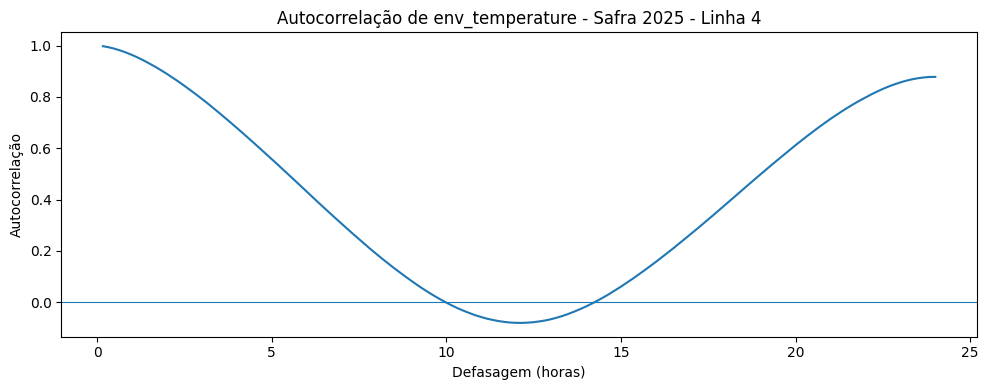

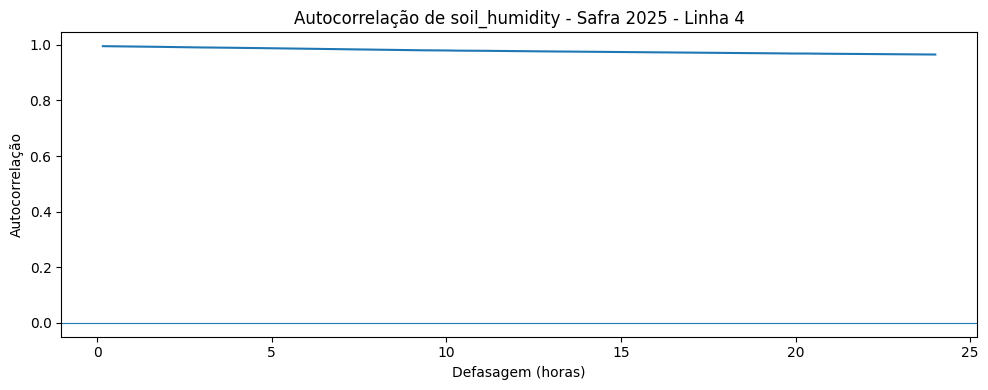

In [29]:
# @title Autocorrelação do exemplo selecionado

autocorr_temp = calcular_autocorrelacao(
    serie_exemplo,
    "env_temperature"
)

autocorr_solo = calcular_autocorrelacao(
    serie_exemplo,
    "soil_humidity"
)

autocorrelacoes_exemplo = pd.concat(
    [autocorr_temp, autocorr_solo],
    ignore_index=True
)

display(autocorrelacoes_exemplo.head())

for variavel, grupo in autocorrelacoes_exemplo.groupby("variavel"):

    plt.figure(figsize=(10, 4))

    plt.plot(
        grupo["lag_horas"],
        grupo["correlacao"]
    )

    plt.axhline(0, linewidth=0.8)
    plt.title(
        f"Autocorrelação de {variavel} - "
        f"Safra {SAFRA_EXEMPLO} - Linha {LINHA_EXEMPLO}"
    )
    plt.xlabel("Defasagem (horas)")
    plt.ylabel("Autocorrelação")
    plt.tight_layout()
    plt.show()

## AUTOCORRELAÇÃO POR SAFRA E LINHA

A análise anterior é repetida para todas as combinações que possuam observações válidas de temperatura do ar e umidade do solo.

Os resultados são armazenados em uma tabela para posterior comparação.

In [15]:
# @title Autocorrelação em todas as séries válidas

resultados_autocorr = []

for _, row in candidatos.iterrows():

    safra = str(row["safra"])
    linha = row["line"]

    serie = preparar_serie_temporal(
        datasets[safra],
        linha
    )

    for variavel in [
        "env_temperature",
        "soil_humidity"
    ]:
        temp = calcular_autocorrelacao(
            serie,
            variavel
        )

        temp["safra"] = safra
        temp["line"] = linha

        resultados_autocorr.append(temp)

autocorrelacoes = pd.concat(
    resultados_autocorr,
    ignore_index=True
)

display(autocorrelacoes.head())

,variavel,lag_passos,lag_horas,correlacao,n,safra,line
0,env_temperature,1,0.167,0.998,17085,2025,4
1,env_temperature,2,0.333,0.994,17079,2025,4
2,env_temperature,3,0.500,0.988,17071,2025,4
3,env_temperature,4,0.667,0.981,17064,2025,4
4,env_temperature,5,0.833,0.973,17057,2025,4


## CORRELAÇÃO TEMPORAL EXPLORATÓRIA ENTRE TEMPERATURA E UMIDADE DO SOLO

Como preparação para a H3, calcula-se a associação entre:

\[
T_{ar}(t)
\quad 	ext{e} \quad
U_{solo}(t + \Delta t)
\]

Nesta etapa o objetivo é apenas **descrever** a relação temporal. A interpretação específica da hipótese H3 será realizada no notebook seguinte.

Apenas defasagens futuras são avaliadas, pois a pergunta de interesse é se a temperatura observada em um instante pode estar associada à umidade do solo em instantes posteriores.

In [16]:
# @title Função de correlação temporal com defasagem

def correlacao_temporal(
    serie,
    max_horas=24,
    min_obs=30
):
    resultados = []

    max_lag = int(max_horas * PASSOS_POR_HORA)

    for lag in range(max_lag + 1):

        temperatura = serie["env_temperature"]
        umidade_futura = (
            serie["soil_humidity"]
            .shift(-lag)
        )

        temp = pd.concat(
            [temperatura, umidade_futura],
            axis=1
        ).dropna()

        if len(temp) < min_obs:
            pearson = np.nan
            spearman = np.nan
        else:
            pearson = temp.iloc[:, 0].corr(
                temp.iloc[:, 1],
                method="pearson"
            )

            spearman = temp.iloc[:, 0].corr(
                temp.iloc[:, 1],
                method="spearman"
            )

        resultados.append({
            "lag_passos": lag,
            "lag_horas": lag / PASSOS_POR_HORA,
            "pearson": pearson,
            "spearman": spearman,
            "n": len(temp),
        })

    return pd.DataFrame(resultados)

,lag_passos,lag_horas,pearson,spearman,n
0,0,0.000,0.404,0.310,17311
1,1,0.167,0.403,0.306,17078
2,2,0.333,0.403,0.306,17072
3,3,0.500,0.403,0.306,17064
4,4,0.667,0.403,0.305,17057


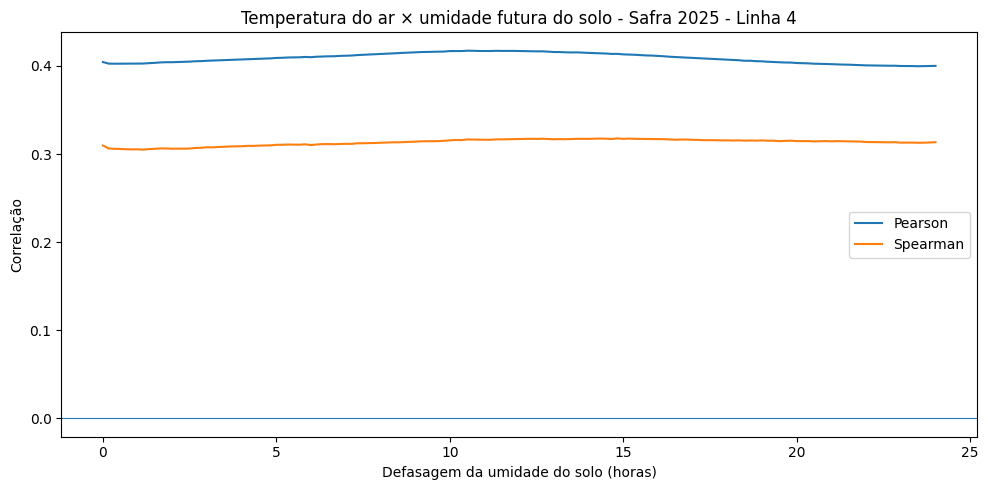

In [30]:
# @title Correlação temporal do exemplo selecionado

corr_exemplo = correlacao_temporal(
    serie_exemplo,
    max_horas=24
)

display(corr_exemplo.head())

plt.figure(figsize=(10, 5))

plt.plot(
    corr_exemplo["lag_horas"],
    corr_exemplo["pearson"],
    label="Pearson"
)

plt.plot(
    corr_exemplo["lag_horas"],
    corr_exemplo["spearman"],
    label="Spearman"
)

plt.axhline(0, linewidth=0.8)

plt.title(
    f"Temperatura do ar × umidade futura do solo - "
    f"Safra {SAFRA_EXEMPLO} - Linha {LINHA_EXEMPLO}"
)

plt.xlabel("Defasagem da umidade do solo (horas)")
plt.ylabel("Correlação")
plt.legend()
plt.tight_layout()
plt.show()

## EXPORTAÇÃO DOS RESULTADOS

Os resultados tabulares desta análise podem ser salvos em `results/time_series/`.

In [31]:
# @title Exportação dos resultados de séries temporais

RESULT_DIR = Path("../results/time_series")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

resumo_temporal.to_csv(
    RESULT_DIR / "resumo_cobertura_temporal.csv",
    index=False
)

disponibilidade.to_csv(
    RESULT_DIR / "disponibilidade_series.csv",
    index=False
)

autocorrelacoes.to_csv(
    RESULT_DIR / "autocorrelacao_series.csv",
    index=False
)

print(f"Resultados salvos em: {RESULT_DIR.resolve()}")

Resultados salvos em: D:\Estudos\Eng Comp\projeto int 4\projeto-integrador-iv-mitha\results\time_series


## PONTOS A VERIFICAR ANTES DA ANÁLISE DA H3

Após executar este notebook, observar principalmente:

1. **Regularidade da coleta:** verificar a quantidade e o tamanho das lacunas temporais.
2. **Linhas com sensores de solo:** identificar quais linhas possuem dados suficientes de `soil_humidity`.
3. **Autocorrelação:** verificar se temperatura e umidade do solo possuem forte dependência dos próprios valores anteriores.
4. **Escala temporal:** observar se tendências ficam mais claras em resolução de 10 minutos, horária ou diária.
5. **Eventos de irrigação:** comparar visualmente mudanças na umidade do solo com os registros de `valve_state`.
6. **Defasagem:** observar em quais atrasos aparecem associações mais negativas entre temperatura e umidade futura do solo.

Esses pontos são utilizados no notebook seguinte para avaliar a H3 modificada sem confundir uma correlação instantânea com uma relação temporal.

## CONCLUSÃO METODOLÓGICA

Este notebook não pretende confirmar ou rejeitar uma hipótese.

Seu objetivo é estabelecer a estrutura temporal dos dados e verificar se as séries possuem qualidade e resolução suficientes para análises com defasagem.

Como as observações são temporalmente dependentes e podem sofrer influência direta da irrigação, uma correlação simples entre temperatura do ar e umidade do solo não deve ser interpretada isoladamente.